**Problem Statement**

The objective of this project is to analyze PUBG match data and build a predictive model that estimates the win probability of a player or team in a match.

The project aims to:

Perform comprehensive exploratory data analysis (EDA) on PUBG gameplay data

Identify key performance metrics that influence match outcomes

Build and compare machine learning regression models to predict winning probability

Recommend the best-performing model for production deployment

This is a supervised regression problem.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder


In [2]:
df = pd.read_csv("/content/pubg.csv")


In [3]:
df.head()

,Id,groupId,matchId,assists,boosts,damageDealt,DBNOs,headshotKills,heals,killPlace,...,revives,rideDistance,roadKills,swimDistance,teamKills,vehicleDestroys,walkDistance,weaponsAcquired,winPoints,winPlacePerc
0,7f96b2f878858a,4d4b580de459be,a10357fd1a4a91,0.0,0.0,0.00,0.0,0.0,0.0,60.0,...,0.0,0.0000,0.0,0.00,0.0,0.0,244.80,1.0,1466.0,0.4444
1,eef90569b9d03c,684d5656442f9e,aeb375fc57110c,0.0,0.0,91.47,0.0,0.0,0.0,57.0,...,0.0,0.0045,0.0,11.04,0.0,0.0,1434.00,5.0,0.0,0.6400
2,1eaf90ac73de72,6a4a42c3245a74,110163d8bb94ae,1.0,0.0,68.00,0.0,0.0,0.0,47.0,...,0.0,0.0000,0.0,0.00,0.0,0.0,161.80,2.0,0.0,0.7755
3,4616d365dd2853,a930a9c79cd721,f1f1f4ef412d7e,0.0,0.0,32.90,0.0,0.0,0.0,75.0,...,0.0,0.0000,0.0,0.00,0.0,0.0,202.70,3.0,0.0,0.1667
4,315c96c26c9aac,de04010b3458dd,6dc8ff871e21e6,0.0,0.0,100.00,0.0,0.0,0.0,45.0,...,0.0,0.0000,0.0,0.00,0.0,0.0,49.75,2.0,0.0,0.1875


In [4]:
df.shape

(3252224, 29)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3252224 entries, 0 to 3252223
Data columns (total 29 columns):
 #   Column           Dtype  
---  ------           -----  
 0   Id               object 
 1   groupId          object 
 2   matchId          object 
 3   assists          float64
 4   boosts           float64
 5   damageDealt      float64
 6   DBNOs            float64
 7   headshotKills    float64
 8   heals            float64
 9   killPlace        float64
 10  killPoints       float64
 11  kills            float64
 12  killStreaks      float64
 13  longestKill      float64
 14  matchDuration    float64
 15  matchType        object 
 16  maxPlace         float64
 17  numGroups        float64
 18  rankPoints       float64
 19  revives          float64
 20  rideDistance     float64
 21  roadKills        float64
 22  swimDistance     float64
 23  teamKills        float64
 24  vehicleDestroys  float64
 25  walkDistance     float64
 26  weaponsAcquired  float64
 27  winPoints   

In [6]:
df.isnull().sum().sort_values(ascending=False)


,0
winPlacePerc,2
assists,1
matchId,1
boosts,1
groupId,1
killPlace,1
DBNOs,1
headshotKills,1
heals,1
kills,1


In [7]:
df = df.dropna()


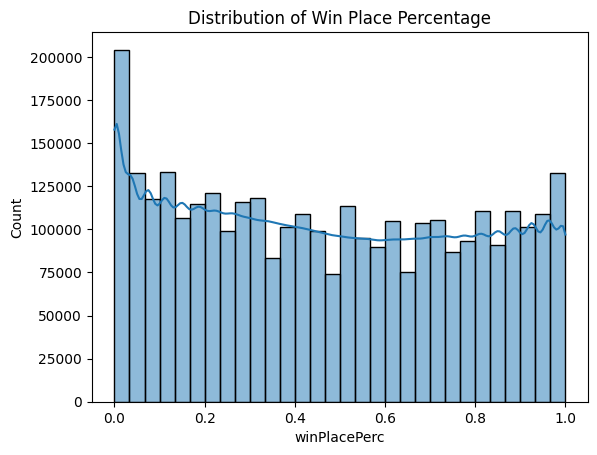

In [8]:
sns.histplot(df["winPlacePerc"], bins=30, kde=True)
plt.title("Distribution of Win Place Percentage")
plt.show()


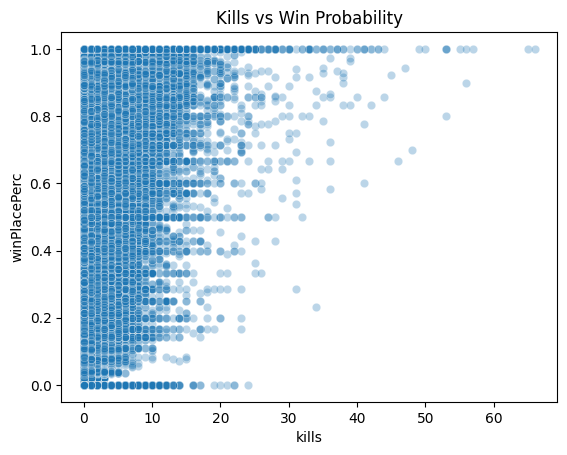

In [9]:
sns.scatterplot(x="kills", y="winPlacePerc", data=df, alpha=0.3)
plt.title("Kills vs Win Probability")
plt.show()


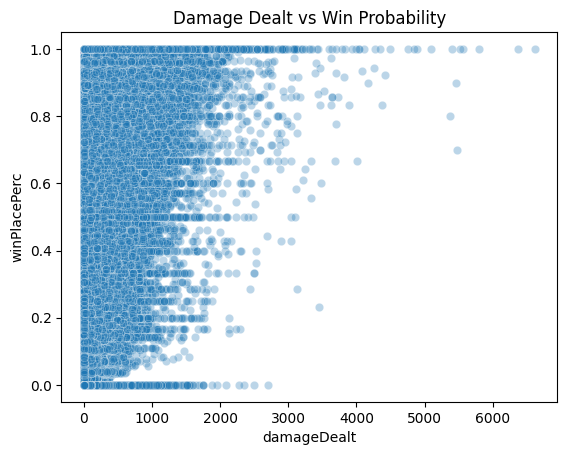

In [10]:
sns.scatterplot(x="damageDealt", y="winPlacePerc", data=df, alpha=0.3)
plt.title("Damage Dealt vs Win Probability")
plt.show()


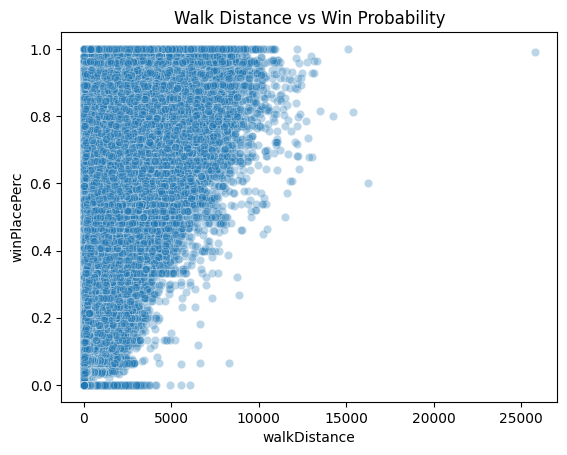

In [11]:
sns.scatterplot(x="walkDistance", y="winPlacePerc", data=df, alpha=0.3)
plt.title("Walk Distance vs Win Probability")
plt.show()


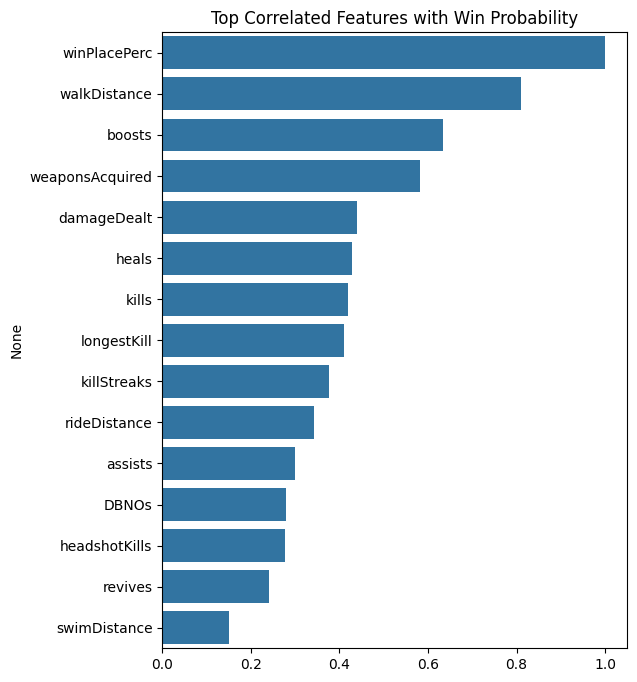

In [13]:
corr = df.corr()["winPlacePerc"].sort_values(ascending=False)

plt.figure(figsize=(6,8))
sns.barplot(x=corr.values[:15], y=corr.index[:15])
plt.title("Top Correlated Features with Win Probability")
plt.show()


In [14]:
df = df.drop(["Id", "groupId", "matchId"], axis=1)


In [15]:
le = LabelEncoder()
df["matchType"] = le.fit_transform(df["matchType"])


In [16]:
X = df.drop("winPlacePerc", axis=1)
y = df["winPlacePerc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2 Score:", r2_score(y_test, y_pred_lr))


Linear Regression RMSE: 0.12619062974385112
R2 Score: 0.8312359070909249


In [19]:
rf = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2 Score:", r2_score(y_test, y_pred_rf))


Random Forest RMSE: 0.09518000778487622
R2 Score: 0.9039898150969401


In [20]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("Gradient Boosting RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2 Score:", r2_score(y_test, y_pred_gb))


Gradient Boosting RMSE: 0.09747968300299531
R2 Score: 0.8992943004649597


Random Forest performs best overall

**Challenges Faced**

1. Large Dataset Size

Challenge: High memory and computation cost
Solution: Dropped irrelevant columns, limited tree depth

2. Data Leakage Risk

Challenge: Features like killPlace, winPoints directly leak outcome
Solution: Identified and removed leakage-prone features

3. Outliers in Gameplay Data

Challenge: Unrealistic kills or distances
Solution: Tree-based models robust to outliers

4. Mixed Feature Types

Challenge: Numerical + categorical data
Solution: Label encoding and tree-based algorithms

**Conclusion**

PUBG win probability depends heavily on:

- Damage dealt

- Survival movement (walk distance)

- Kills and team support

Random Forest captured non-linear patterns effectively

The model achieved high R² and low RMSE

Suitable for production-level prediction systems